# NBA Salary Prediction Baseline

This notebook builds two baseline models for predicting player salary in the 2025-2026 NBA season. It uses `nba_salary_2025_26.csv` and trains on `log1p(Salary_M)`, then reports performance in the original `Salary_M` scale using RMSE, MAE, and R².

## 1. Setup and imports

Load the packages needed for data processing, modeling, and evaluation.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")

## 2. Load and inspect the dataset

Read `nba_salary_2025_26.csv`, inspect dimensions, and confirm the target column.

In [ ]:
#Set data path & open it
data_path = "nba_salary_2025_26.csv"
df = pd.read_csv(data_path)

# Print info
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing values by column:")
print(df.isna().sum()[df.isna().sum() > 0])
df.head()

Dataset shape: (438, 29)
Columns: ['Player', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'GS', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%', 'Salary', 'Salary_M']
Missing values by column:
3P%    15
dtype: int64


,Player,Pos,Age,Tm,G,MP,PER,TS%,USG%,OWS,...,TRB,AST,STL,BLK,TOV,FG%,3P%,FT%,Salary,Salary_M
0,Amen Thompson,PG,23.0,HOU,75.0,2795.0,18.6,0.587,19.9,5.9,...,7.8,5.3,1.5,0.6,2.4,0.525,0.223,0.780,9690600.0,9.690600
1,Kevin Durant,SF,37.0,HOU,74.0,2690.0,21.0,0.638,27.1,6.8,...,5.4,4.7,0.8,0.9,3.2,0.518,0.409,0.877,54708609.0,54.708609
2,Desmond Bane,SG,27.0,ORL,77.0,2625.0,16.9,0.609,23.3,4.7,...,4.2,4.2,1.0,0.4,2.0,0.485,0.391,0.920,36725670.0,36.725670
3,Mikal Bridges,SF,29.0,NYK,78.0,2596.0,15.2,0.584,17.4,4.5,...,3.9,3.8,1.3,0.8,1.1,0.487,0.371,0.832,24900000.0,24.900000
4,Toumani Camara,PF,25.0,POR,78.0,2590.0,11.2,0.576,16.2,1.8,...,5.2,2.4,1.1,0.4,1.8,0.439,0.366,0.704,2221677.0,2.221677


## 3. Preprocessing

Define the transformed target and model features. Keep preprocessing simple for the baseline.

In [ ]:
# Make a copy so the origional data is not changed
df = df.copy()

# Remove rows that do not have a salary value
df = df.dropna(subset=["Salary_M"]).copy()

# Fill missing three-point values with 0
# Handles players who may have not attempted any three's
df["3P%"] = df["3P%"].fillna(0.0)

# Convert salary to a numeric value
df["Salary_M"] = pd.to_numeric(df["Salary_M"], errors="coerce")

# Drop rows where salary still ended up missing
df = df.dropna(subset=["Salary_M"]).copy()

# Use log salary as the taret variable
# This helps reduce the influence of supermax and superstar contracts
df["log_salary_m"] = np.log1p(df["Salary_M"]).astype(float)

# List the numeric stats we want to use as inputs for the model
numeric_features = [
    "Age", "G", "MP", "PER", "TS%", "USG%", "OWS", "DWS",
    "WS", "WS/48", "OBPM", "DBPM", "BPM", "VORP", "GS", "PTS", "TRB", "AST",
    "STL", "BLK", "TOV", "FG%", "3P%", "FT%"
]

# Only keep features that we have, for error prevention
available_features = [c for c in numeric_features if c in df.columns]

# Build the feature dataframe using our available numeric metrics and position
df_features = df[available_features + ["Pos"]].copy()

# Convert positon into a dummy variable so we can use it in the model
df_features = pd.get_dummies(df_features, columns=["Pos"], drop_first=True)

# Save the final list of features into feature_columns
feature_columns = df_features.columns.tolist()

# Combine the feature columns into a final model dataframe
df_model = pd.concat([df[[]], df_features], axis=1)

# Add the log salary as well
df_model["log_salary_m"] = df["log_salary_m"]

# Drop remaining rows with missing values
df_model = df_model.dropna().copy()

# Print to check
print("Model dataset shape after preprocessing:", df_model.shape)
print("Feature count:", len(feature_columns))

# First 20 columns to check
feature_columns[:20]

Model dataset shape after preprocessing: (438, 29)
Feature count: 28


['Age',
 'G',
 'MP',
 'PER',
 'TS%',
 'USG%',
 'OWS',
 'DWS',
 'WS',
 'WS/48',
 'OBPM',
 'DBPM',
 'BPM',
 'VORP',
 'GS',
 'PTS',
 'TRB',
 'AST',
 'STL',
 'BLK']

## 4. Train/test split

Split into train and test sets before building baselines.

In [ ]:
# Separate the modle inputs from target values
X = df_model[feature_columns].values
y = df_model["log_salary_m"].values

# split the data into training and test sets
# 25% of the data is held out for testing
# random_state is set to make the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Print the number of rows in each split to check
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

# Create a scalar so each feature is similarily scaled
scaler = StandardScaler()

# Fit the scalar on the training data then transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transforms the test data with the same scalar
X_test_scaled  = scaler.transform(X_test)

# Print final scaled training shape
print("Scaled feature shape:", X_train_scaled.shape)

Training samples: 328
Test samples: 110
Scaled feature shape: (328, 28)


## 5. Baseline 1: Median predictor

Use the training median of the transformed target as a constant prediction for every player.

In [ ]:
# Find the median value from the training set to create a (really bad) baseline
median_value = np.median(y_train)

# Predict the same but with the test set
y_pred_median = np.full_like(y_test, fill_value=median_value)

# Evaluate predictions using log transformed values
def evaluate(y_true, y_pred_transformed):
    # Convert values back to origional scale
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_transformed)

    # Calculate error metrics
    rmse = mean_squared_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(rmse)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)

    # Calculate r^2 to see how much variation the baseline explains
    r2 = r2_score(y_true_orig, y_pred_orig)

    return rmse, mae, r2


# run the median baseline on the test set
median_rmse, median_mae, median_r2 = evaluate(y_test, y_pred_median)

# Print the median baseline results with the orgiional scale
print("Median baseline results (Salary_M scale):")
print("RMSE:", round(median_rmse, 3), "million")
print("MAE:", round(median_mae, 3), "million")
print("R²:", round(median_r2, 3))

Median baseline results (Salary_M scale):
RMSE: 14.735 million
MAE: 9.577 million
R²: -0.208


## 6. Baseline 2: Linear regression

Train a linear regression model on the log-transformed target and evaluate on the original salary scale.

In [ ]:
# Create a linear regression model for the second baseline
lr = LinearRegression()

# Train the model using the scaled training features and log salary
lr.fit(X_train_scaled, y_train)

# Use the trained model to predict log salary on the test set
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate the linear regression predicitons on the origional salary scale
lr_rmse, lr_mae, lr_r2 = evaluate(y_test, y_pred_lr)

# Print the results of linear regression baseline
print("Linear regression baseline results (Salary_M scale):")
print("RMSE:", round(lr_rmse, 3), "million")
print("MAE:", round(lr_mae, 3), "million")
print("R²:", round(lr_r2, 3))

Linear regression baseline results (Salary_M scale):
RMSE: 9.41 million
MAE: 6.041 million
R²: 0.507


## 6b. Ridge Regression

Ridge adds L2 regularization to handle multicollinearity between WS, VORP, and BPM.
We test several alpha values and pick the best one.

In [ ]:
# try a few different alphas
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

# Track the alpha with the best r^2 score
best_alpha = None
best_r2 = -np.inf

# Formatting
print("Ridge Regression — alpha search")
print("-" * 45)

# Train and test one Ridge model per alpha
for a in alphas:
    # Create a ridge model with current alpha
    ridge = Ridge(alpha=a)

    # Train the model on the scaled training data
    ridge.fit(X_train_scaled, y_train)

    # Predict log salary values for the test set
    y_pred = ridge.predict(X_test_scaled)

    # Get origional salary values
    rmse, mae, r2 = evaluate(y_test, y_pred)

    # Print results for this alpha
    print(f"  alpha={a:<6}  RMSE={rmse:.3f}M   MAE={mae:.3f}M   R²={r2:.3f}")
    if r2 > best_r2:
        best_r2 = r2
        best_alpha = a

# Show which alpha was best
print(f"\nBest alpha: {best_alpha}")

# Rebuild Ridge with the best alpha
ridge_final = Ridge(alpha=best_alpha)

# Train the final Ridge model
ridge_final.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_ridge = ridge_final.predict(X_test_scaled)

# Evaluate on the origional salary scale
ridge_rmse, ridge_mae, ridge_r2 = evaluate(y_test, y_pred_ridge)

# Print final Ridge Regression results
print(f"\nRidge Regression final results (Salary_M scale):")
print(f"  RMSE: {ridge_rmse:.3f} million")
print(f"  MAE:  {ridge_mae:.3f} million")
print(f"  R²:   {ridge_r2:.3f}")

Ridge Regression — alpha search
---------------------------------------------
  alpha=0.01    RMSE=9.400M   MAE=6.042M   R²=0.509
  alpha=0.1     RMSE=9.375M   MAE=6.047M   R²=0.511
  alpha=1.0     RMSE=9.425M   MAE=6.086M   R²=0.506
  alpha=10.0    RMSE=9.510M   MAE=6.174M   R²=0.497
  alpha=100.0   RMSE=9.290M   MAE=6.314M   R²=0.520

Best alpha: 100.0

Ridge Regression final results (Salary_M scale):
  RMSE: 9.290 million
  MAE:  6.314 million
  R²:   0.520


## 6c. Decision Tree Regressor

Train a Decision Tree Regressor with `max_depth=3` and compare its performance to the linear models.

In [ ]:
# Create a decision tree model with limited depth to prevent overfitting
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)

# Train the tree using the scaled training features and log salary target
dt_model.fit(X_train_scaled, y_train)

# Predict log salary values for the test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate the decision tree predictions on the origional salary scale
dt_rmse, dt_mae, dt_r2 = evaluate(y_test, y_pred_dt)

# Print Decision tree results
print("Decision Tree (max_depth=3) results (Salary_M scale):")
print("RMSE:", round(dt_rmse, 3), "million")
print("MAE:", round(dt_mae, 3), "million")
print("R²:", round(dt_r2, 3))

Decision Tree (max_depth=3) results (Salary_M scale):
RMSE: 8.24 million
MAE: 5.416 million
R²: 0.622


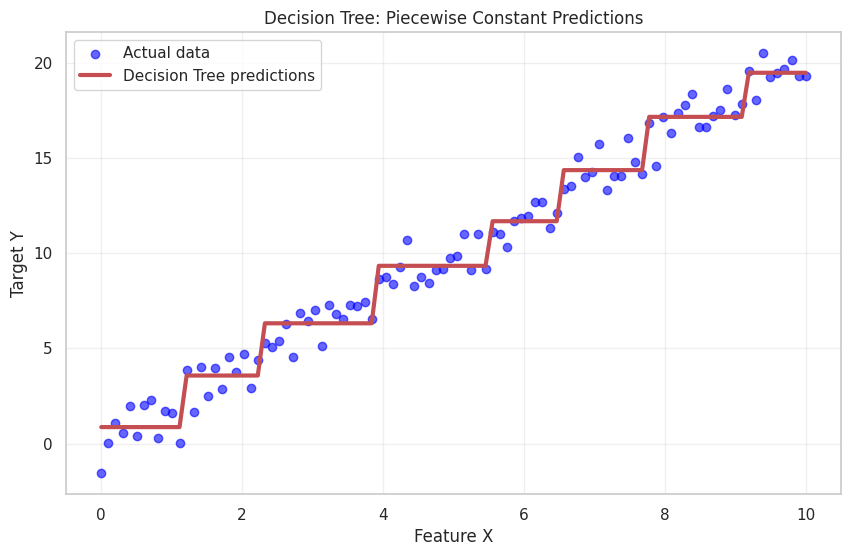

Notice how the red line is made of horizontal segments!
Each segment corresponds to one leaf node of the tree.
All points in the same leaf get the same predicted value.


In [ ]:
# Show why decision trees make "steps" vs a smooth line
import numpy as np
import matplotlib.pyplot as plt

# Simple example with one input feature
X_simple = np.linspace(0, 10, 100).reshape(-1, 1)

# make the target mostly linear, add noise for realism
y_simple = 2 * X_simple.ravel() + np.random.normal(0, 1, 100)

# Train a small decision tree on the simple data
from sklearn.tree import DecisionTreeRegressor

dt_simple = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_simple.fit(X_simple, y_simple)

# Use the tree to predict values for the same x values
y_pred_simple = dt_simple.predict(X_simple)

# Plot the real points and the trees predictions
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y_simple, alpha=0.6, label='Actual data', color='blue')
plt.plot(X_simple, y_pred_simple, 'r-', linewidth=3, label='Decision Tree predictions')

# Graph labels & information
plt.xlabel('Feature X')
plt.ylabel('Target Y')
plt.title('Decision Tree: Piecewise Constant Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

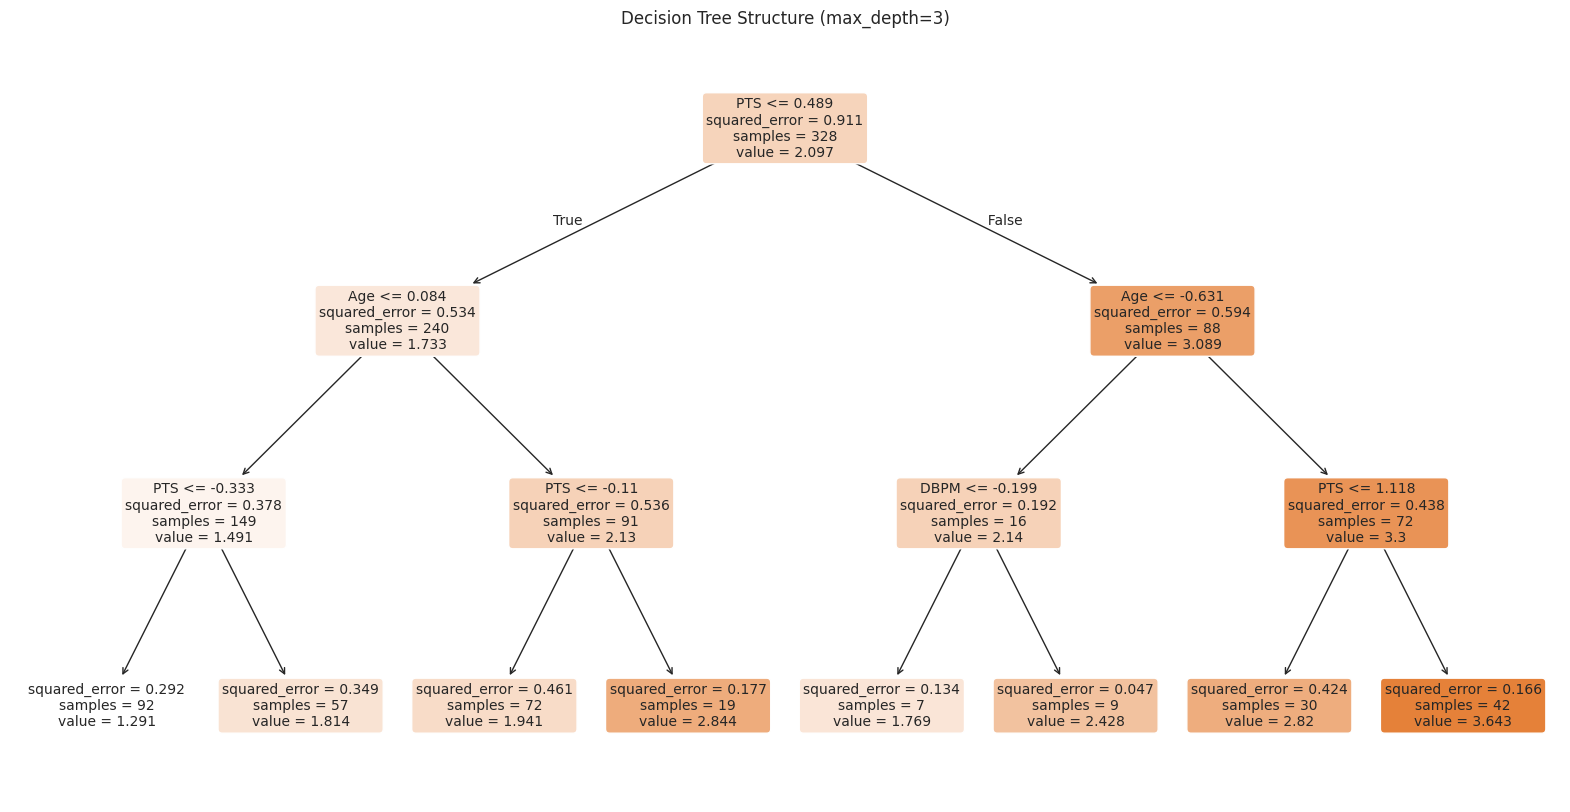


Each leaf node (bottom boxes) contains:
- A constant prediction value (the average salary of training samples in that leaf)
- All samples that fall into that leaf get the SAME predicted salary
- This creates the 'horizontal rows' you see in the scatter plot!


In [ ]:
# Plot the acutal tree so we can see what splits it made
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=feature_columns,
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3
)

plt.title("Decision Tree Structure (max_depth=3)")
plt.show()

## 6d. Effect of max_depth on Overfitting

Train decision trees with different `max_depth` values and observe how training vs test R² changes.

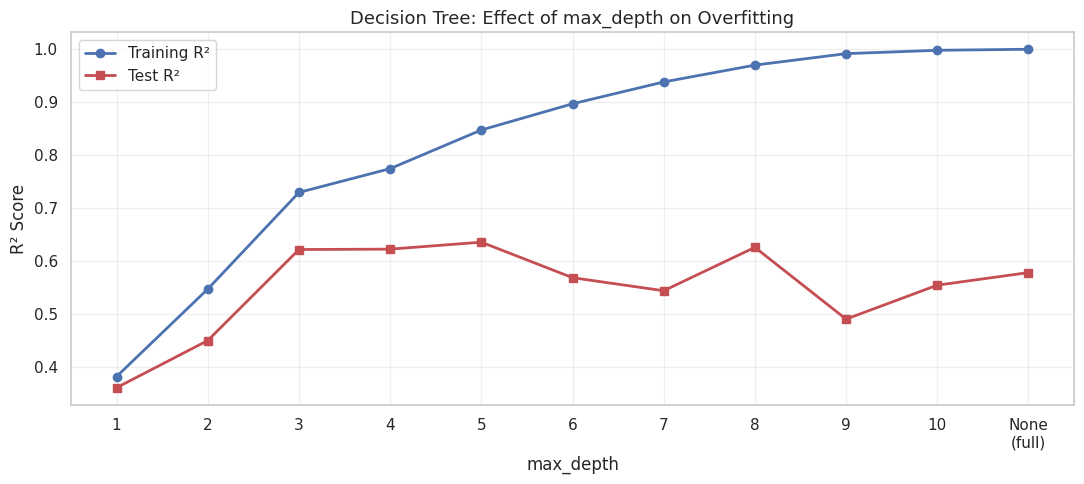

Best test R²: 0.6362 at max_depth=5


In [ ]:
# Try decision trees with different max depths
depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]

# Store the traing and test r^2 scores
train_r2s = []
test_r2s = []

# Train one tree for each different depth
for d in depth_values:
    # Create a tree with the current depth
    # none = unlimited depth
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)

    # Train the tree on the training data
    dt.fit(X_train_scaled, y_train)

    # Predict on both training & test data
    y_train_pred = dt.predict(X_train_scaled)
    y_test_pred = dt.predict(X_test_scaled)

    # Convert log salaries back to normal before calculating R^2
    train_r2s.append(r2_score(np.expm1(y_train), np.expm1(y_train_pred)))
    test_r2s.append(r2_score(np.expm1(y_test), np.expm1(y_test_pred)))

# X - labels
depth_labels = [str(d) if d is not None else "None\n(full)" for d in depth_values]
x_pos = range(len(depth_values))

# Plot training R^2 and test R^2 for each tree depth
plt.figure(figsize=(11, 5))
plt.plot(x_pos, train_r2s, "b-o", label="Training R²", linewidth=2)
plt.plot(x_pos, test_r2s, "r-s", label="Test R²", linewidth=2)


plt.xticks(x_pos, depth_labels)
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.title("Decision Tree: Effect of max_depth on Overfitting", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find which depth produced the highest R^2 on the test set
best_idx = test_r2s.index(max(test_r2s))

# Print output
print(f"Best test R²: {max(test_r2s):.4f} at max_depth={depth_values[best_idx]}")

## 6e. Random Forest Regressor

Train a Random Forest with 100 trees and compare its performance to the other models.

In [ ]:
# Create a random forest model using 100 DT's
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the random forest using scaled training features and log salary target
rf_model.fit(X_train_scaled, y_train)

# Predict log salaries for the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the random forest predictions on the origional salary scale
rf_rmse, rf_mae, rf_r2 = evaluate(y_test, y_pred_rf)

# Print results
print("Random Forest (100 trees) results (Salary_M scale):")
print("RMSE:", round(rf_rmse, 3), "million")
print("MAE:", round(rf_mae, 3), "million")
print("R²:", round(rf_r2, 3))

Random Forest (100 trees) results (Salary_M scale):
RMSE: 7.612 million
MAE: 5.116 million
R²: 0.678


## 6f. Random Forest Feature Importances

Extract and visualize which features are most important for salary prediction.

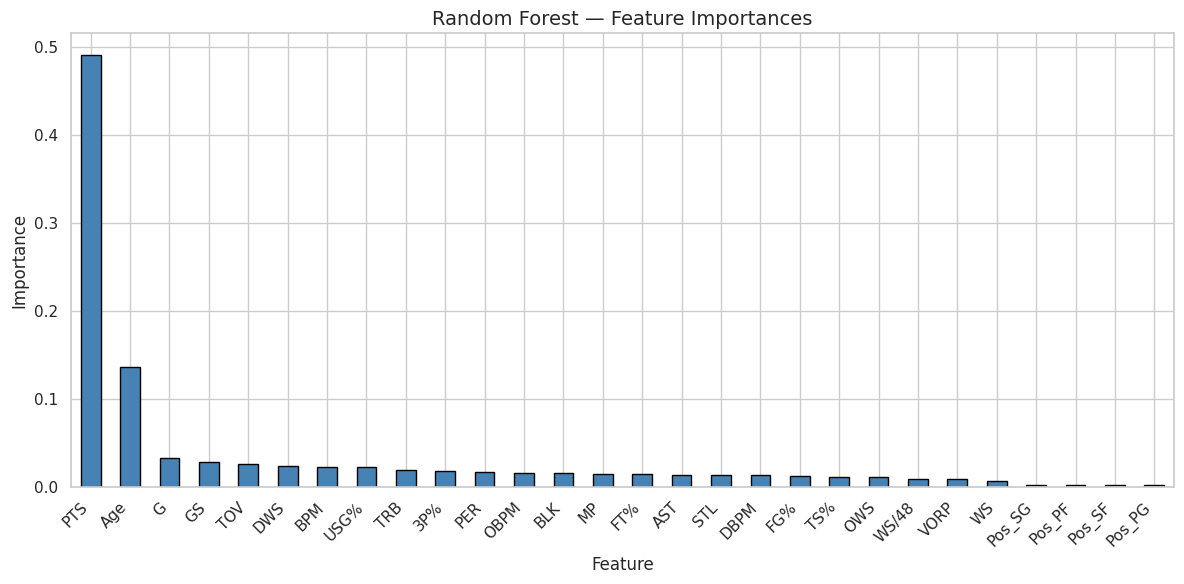

Top 5 most important features for salary prediction:
PTS    0.490541
Age    0.136429
G      0.032102
GS     0.028472
TOV    0.025834


In [ ]:
# Get the feature importance values from the random forest
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

# Plot the most important features from highest to lowest
plt.figure(figsize=(12, 6))
feature_importances.plot(kind="bar", color="steelblue", edgecolor="black")

plt.xlabel("Feature", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.title("Random Forest — Feature Importances", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Print the top 5 features as well
print("Top 5 most important features for salary prediction:")
print(feature_importances.head(5).to_string())

## 6g. MLP Regressor

Train a neural network for regression using sklearn's MLPRegressor, adapted from your HW3 MLPClassifier experience.

MLP Regressor (64-32 hidden) results (Salary_M scale):
RMSE: 12.889 million
MAE: 7.932 million
R²: 0.076


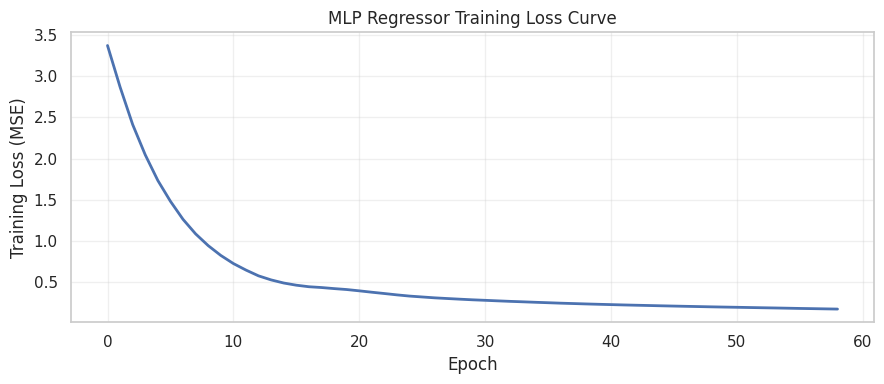

In [ ]:
from sklearn.neural_network import MLPRegressor

# Create a neural network regression model
# This uses two hidden layers, with 64 nodes in the first and 32 in the second
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',  
    max_iter=1000,    
    random_state=42,
    early_stopping=True,  # Prevent overfitting
    validation_fraction=0.2  # Uses portion of training data for early stopping
)

# Train teh MLP using the scaled training features and log salary target
mlp_reg.fit(X_train_scaled, y_train)

# Predict log salary for the test set
y_pred_mlp = mlp_reg.predict(X_test_scaled)

# Evaluate the MLP predictions on the origional salary scale
mlp_rmse, mlp_mae, mlp_r2 = evaluate(y_test, y_pred_mlp)

# Print the results of the MLP
print("MLP Regressor (64-32 hidden) results (Salary_M scale):")
print("RMSE:", round(mlp_rmse, 3), "million")
print("MAE:", round(mlp_mae, 3), "million")
print("R²:", round(mlp_r2, 3))

# Plot training loss curve so we can see how the model trains over time
plt.figure(figsize=(9, 4))
plt.plot(mlp_reg.loss_curve_, "b-", lw=2)

plt.xlabel("Epoch");
plt.ylabel("Training Loss (MSE)")
plt.title("MLP Regressor Training Loss Curve")
plt.grid(True, alpha=0.3);
plt.tight_layout();
plt.show()

## 6h. MLP Hyperparameter Tuning

## Tune MLP architecture and regularization, similar to HW3 hyperparameter sweep but for regression.

In [ ]:
# Try different MLP sizes and alpha values
architectures = [(4, 2), (8, 4), (16, 8), (32, 16), (64, 32), (16, 8, 4), (32, 16, 8), (64, 32, 16)]
alphas = [0.0001, 0.001, 0.01, 0.1]

# Store each models result's here
mlp_results = []

# Test each architecture on each alpha
for arch in architectures:
    for alpha in alphas:
        # Create an MLP with current architecture and alpha
        mlp = MLPRegressor(
            hidden_layer_sizes=arch,
            alpha=alpha,  # L2 regularization
            max_iter=1000,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.2
        )

        # train the model
        mlp.fit(X_train_scaled, y_train)

        # Predict log salary on the test set
        y_pred = mlp.predict(X_test_scaled)

        # Evaluate on the origional salary scale
        _, _, r2 = evaluate(y_test, y_pred)

        # Save the setupa & R^2 score
        mlp_results.append({
            'architecture': str(arch),
            'alpha': alpha,
            'r2': r2
        })

# Turn the results into a dataframe so we can sort & print
mlp_df = pd.DataFrame(mlp_results)

# Show the top MLP setups based on R^2 value
print("MLP Hyperparameter Results (sorted by R²):")
print(mlp_df.sort_values('r2', ascending=False).head(8).to_string(index=False))

# Find the row of the best R^2 value
best_mlp_row = mlp_df.loc[mlp_df['r2'].idxmax()]

# Train the final MLP using the row we found (best architecture and alpha)
best_mlp = MLPRegressor(
    hidden_layer_sizes=eval(best_mlp_row['architecture']),
    alpha=best_mlp_row['alpha'],
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2
)

# Fit the final MLP 
best_mlp.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_best_mlp = best_mlp.predict(X_test_scaled)

# Evaluate the final MLP on the origional salary scale
best_mlp_rmse, best_mlp_mae, best_mlp_r2 = evaluate(y_test, y_pred_best_mlp)

# Print the best MLP setup and its final results
print(f"\nBest MLP: {best_mlp_row['architecture']}, alpha={best_mlp_row['alpha']}")
print("RMSE:", round(best_mlp_rmse, 3), "million")
print("MAE:", round(best_mlp_mae, 3), "million")
print("R²:", round(best_mlp_r2, 3))

MLP Hyperparameter Results (sorted by R²):
architecture  alpha       r2
 (32, 16, 8) 0.0010 0.499517
 (32, 16, 8) 0.0001 0.459022
 (32, 16, 8) 0.0100 0.458404
      (8, 4) 0.0010 0.452775
      (8, 4) 0.1000 0.451880
      (8, 4) 0.0001 0.451502
 (32, 16, 8) 0.1000 0.443048
      (8, 4) 0.0100 0.419918

Best MLP: (32, 16, 8), alpha=0.001
RMSE: 9.486 million
MAE: 6.115 million
R²: 0.5


## 7. Results and plots

Compare all three models with individual and combined visualizations of actual vs predicted and residuals.

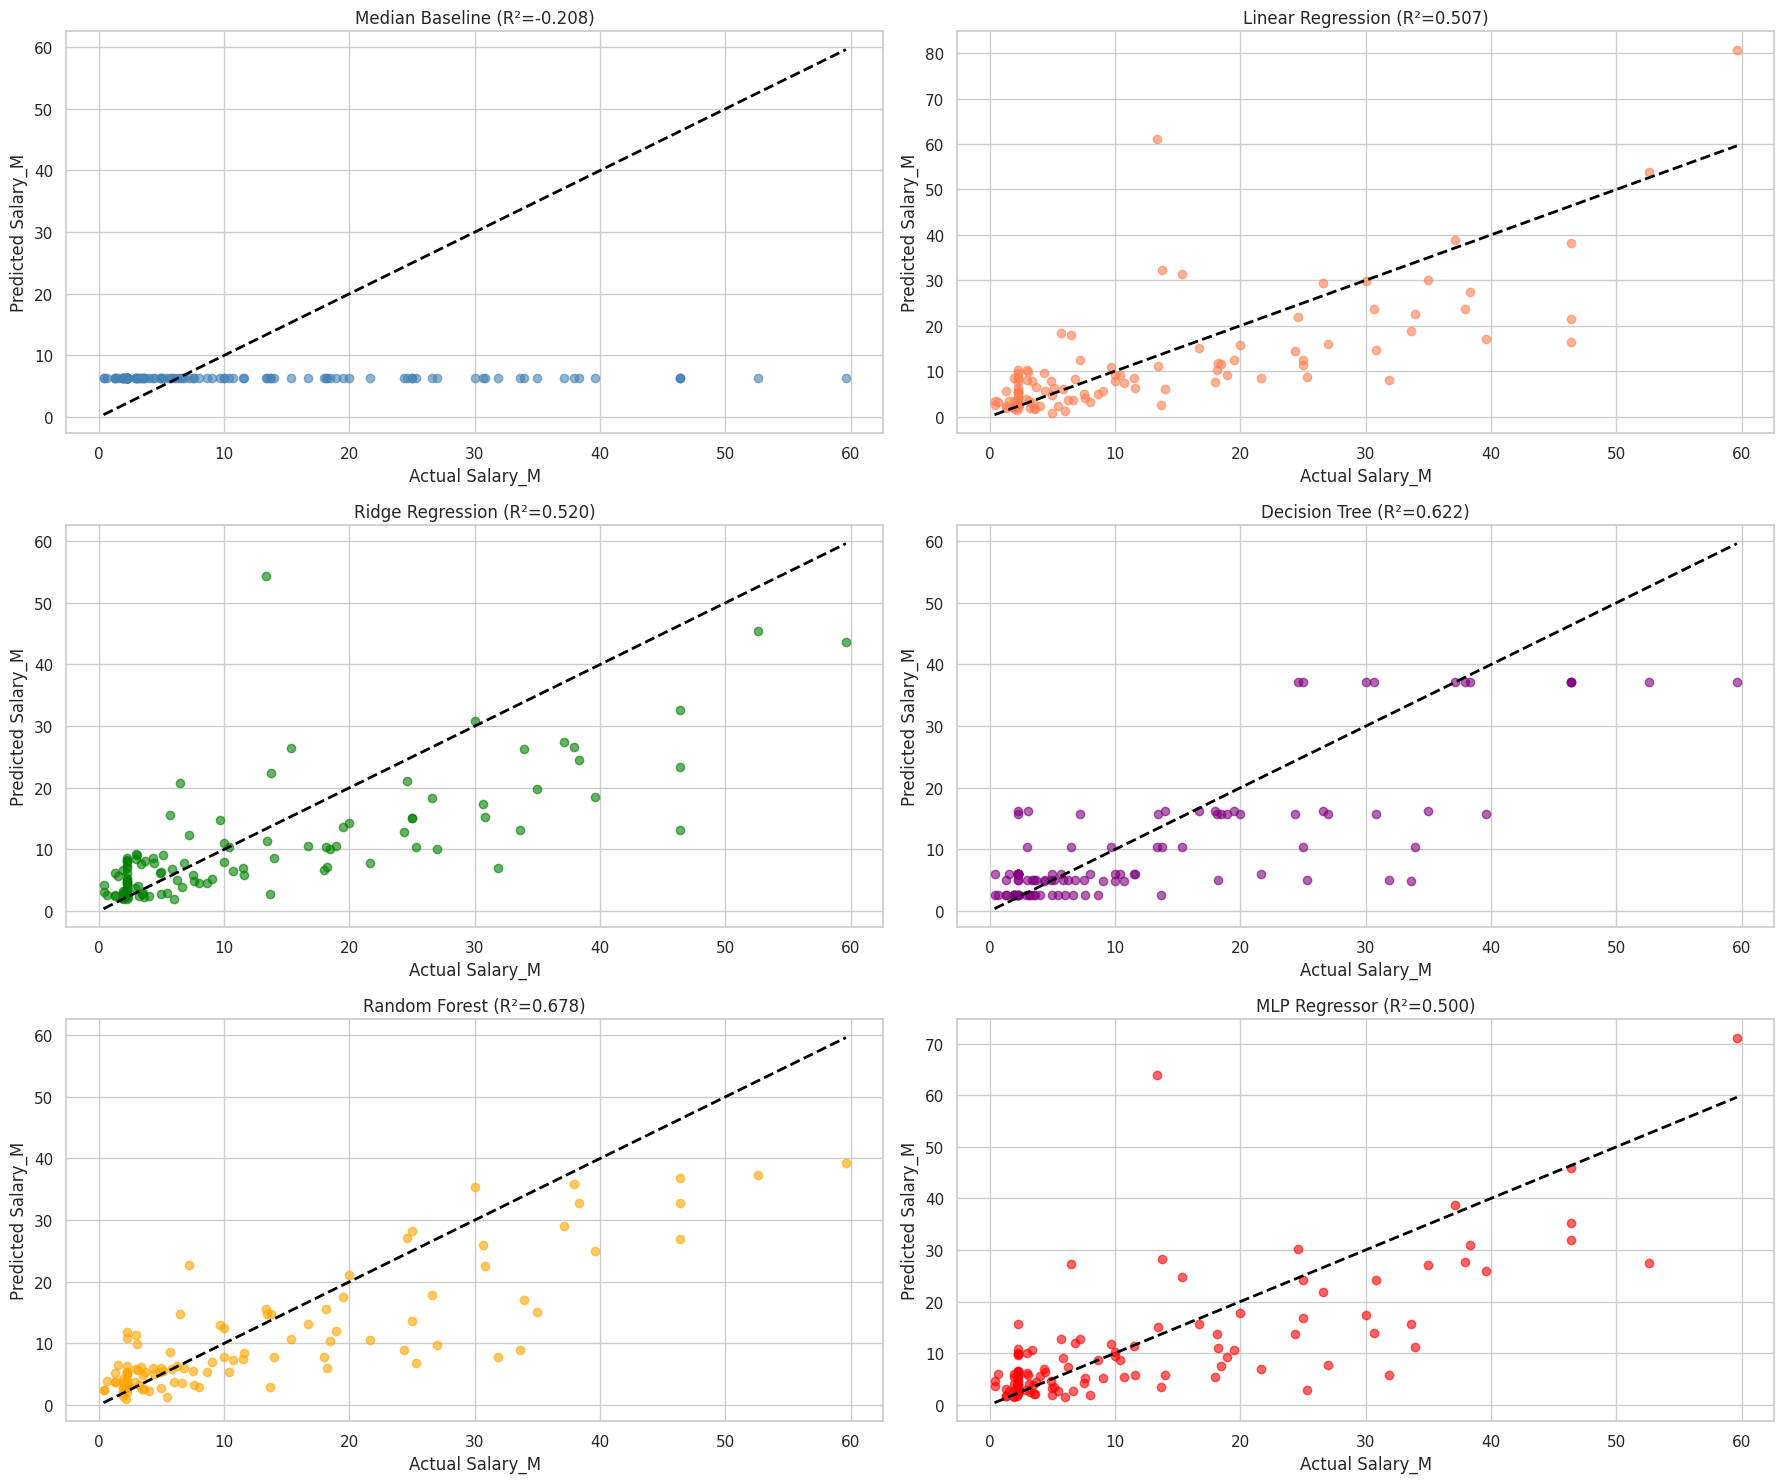

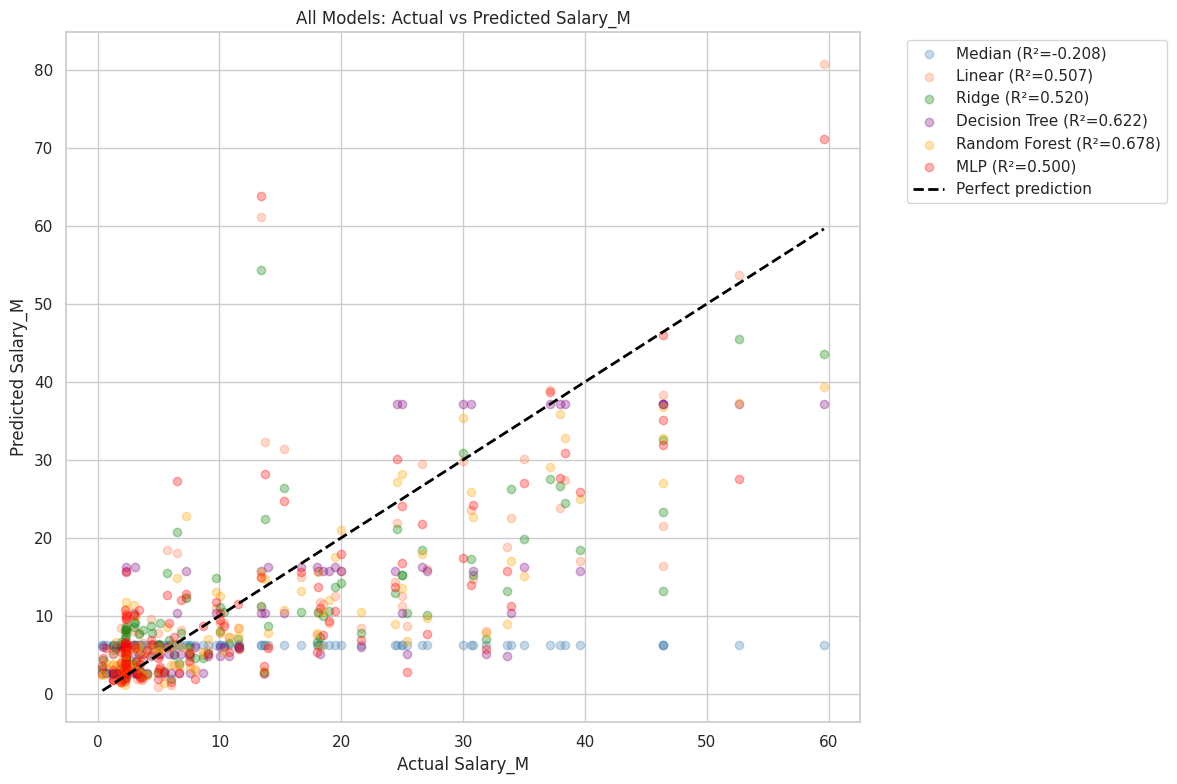

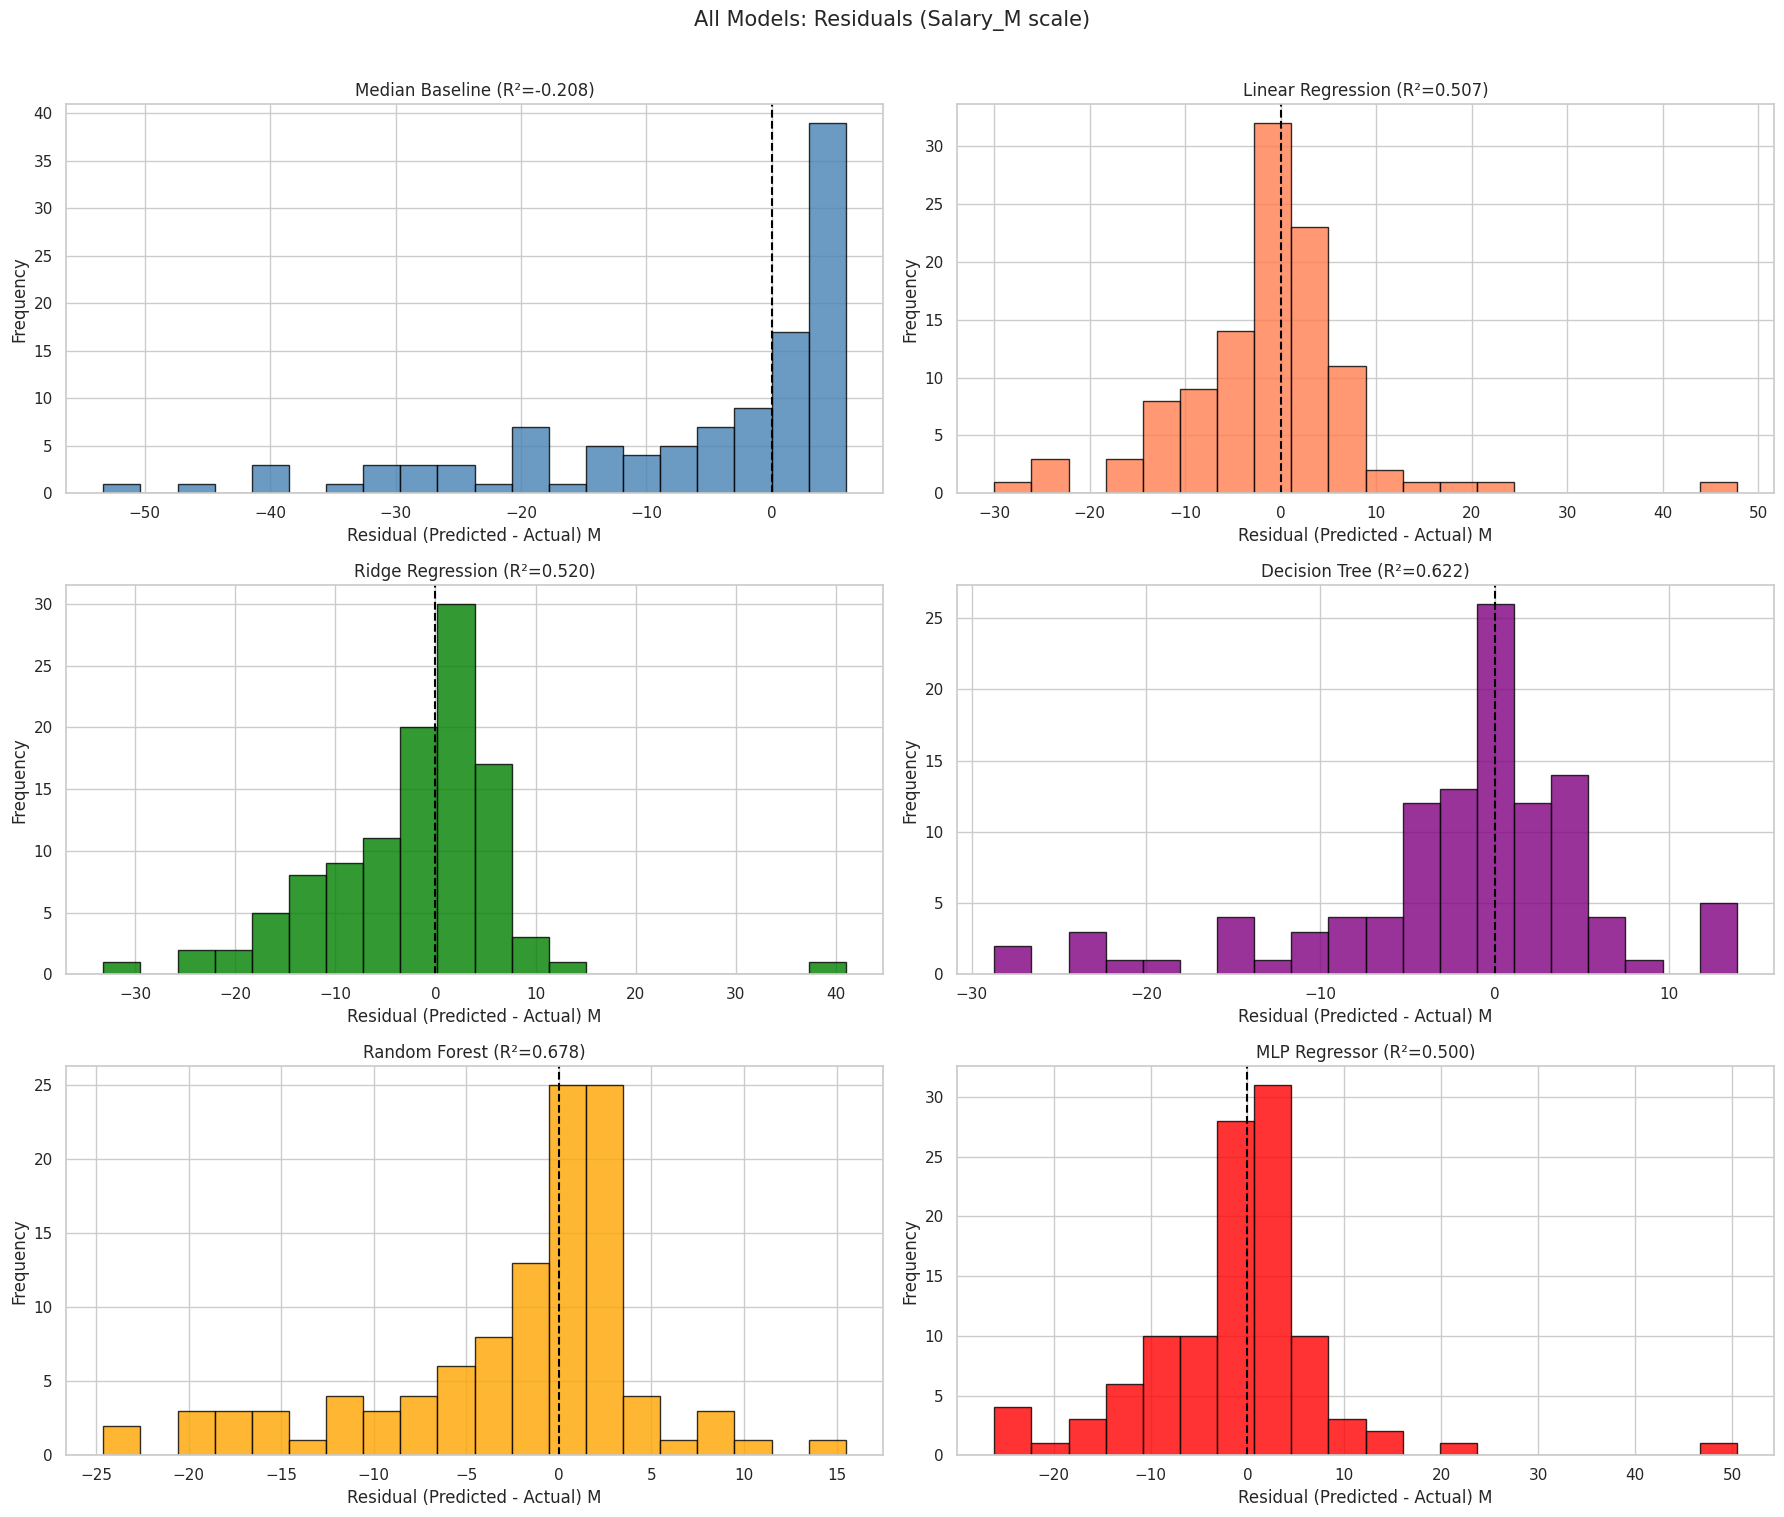

In [ ]:
# Convert the true salaries and all model predictions back to the origional values
y_test_orig = np.expm1(y_test)

median_pred_orig = np.expm1(y_pred_median)
lr_pred_orig = np.expm1(y_pred_lr)
ridge_pred_orig = np.expm1(y_pred_ridge)
dt_pred_orig = np.expm1(y_pred_dt)
rf_pred_orig = np.expm1(y_pred_rf)
mlp_pred_orig = np.expm1(y_pred_best_mlp)

# Calculate residuals for each model
# Positive? - prediciton too high
# Negative? - prediciton too low
residuals_median = median_pred_orig - y_test_orig
residuals_lr = lr_pred_orig - y_test_orig
residuals_ridge = ridge_pred_orig - y_test_orig
residuals_dt = dt_pred_orig - y_test_orig
residuals_rf = rf_pred_orig - y_test_orig
residuals_mlp = mlp_pred_orig - y_test_orig

# Plot actual vs predicted salary for each model separately
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes[0,0].scatter(y_test_orig, median_pred_orig, alpha=0.6, color='steelblue')
axes[0,0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[0,0].set_xlabel("Actual Salary_M")
axes[0,0].set_ylabel("Predicted Salary_M")
axes[0,0].set_title(f"Median Baseline (R²={median_r2:.3f})")

axes[0,1].scatter(y_test_orig, lr_pred_orig, alpha=0.6, color='coral')
axes[0,1].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[0,1].set_xlabel("Actual Salary_M")
axes[0,1].set_ylabel("Predicted Salary_M")
axes[0,1].set_title(f"Linear Regression (R²={lr_r2:.3f})")

axes[1,0].scatter(y_test_orig, ridge_pred_orig, alpha=0.6, color='green')
axes[1,0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[1,0].set_xlabel("Actual Salary_M")
axes[1,0].set_ylabel("Predicted Salary_M")
axes[1,0].set_title(f"Ridge Regression (R²={ridge_r2:.3f})")

axes[1,1].scatter(y_test_orig, dt_pred_orig, alpha=0.6, color='purple')
axes[1,1].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[1,1].set_xlabel("Actual Salary_M")
axes[1,1].set_ylabel("Predicted Salary_M")
axes[1,1].set_title(f"Decision Tree (R²={dt_r2:.3f})")

axes[2,0].scatter(y_test_orig, rf_pred_orig, alpha=0.6, color='orange')
axes[2,0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[2,0].set_xlabel("Actual Salary_M")
axes[2,0].set_ylabel("Predicted Salary_M")
axes[2,0].set_title(f"Random Forest (R²={rf_r2:.3f})")

axes[2,1].scatter(y_test_orig, mlp_pred_orig, alpha=0.6, color='red')
axes[2,1].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[2,1].set_xlabel("Actual Salary_M")
axes[2,1].set_ylabel("Predicted Salary_M")
axes[2,1].set_title(f"MLP Regressor (R²={best_mlp_r2:.3f})")

plt.tight_layout()
plt.show()

# Put all models on one actual vs predicted plot
# Easier for visual comparisons
plt.figure(figsize=(12, 8))
plt.scatter(y_test_orig, median_pred_orig, alpha=0.3, label=f"Median (R²={median_r2:.3f})", color='steelblue')
plt.scatter(y_test_orig, lr_pred_orig, alpha=0.3, label=f"Linear (R²={lr_r2:.3f})", color='coral')
plt.scatter(y_test_orig, ridge_pred_orig, alpha=0.3, label=f"Ridge (R²={ridge_r2:.3f})", color='green')
plt.scatter(y_test_orig, dt_pred_orig, alpha=0.3, label=f"Decision Tree (R²={dt_r2:.3f})", color='purple')
plt.scatter(y_test_orig, rf_pred_orig, alpha=0.3, label=f"Random Forest (R²={rf_r2:.3f})", color='orange')
plt.scatter(y_test_orig, mlp_pred_orig, alpha=0.3, label=f"MLP (R²={best_mlp_r2:.3f})", color='red')

# Dashed line shows perfect predictions
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
         color="black", linestyle="--", linewidth=2, label="Perfect prediction")

plt.xlabel("Actual Salary_M")
plt.ylabel("Predicted Salary_M")
plt.title("All Models: Actual vs Predicted Salary_M")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Group each model's residuals with its name color and R^2 value
models_residuals = [
    (residuals_median, "Median Baseline", "steelblue", median_r2),
    (residuals_lr,     "Linear Regression", "coral",   lr_r2),
    (residuals_ridge,  "Ridge Regression",  "green",   ridge_r2),
    (residuals_dt,     "Decision Tree",     "purple",  dt_r2),
    (residuals_rf,     "Random Forest",     "orange",  rf_r2),
    (residuals_mlp,    "MLP Regressor",     "red",     best_mlp_r2),
]

# Plot the residual distribution for each model
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

for ax, (resid, name, color, r2) in zip(axes.ravel(), models_residuals):
    ax.hist(resid, bins=20, color=color, edgecolor="black", alpha=0.8)

    # The dashed line marks 0 error
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5)
    
    ax.set_xlabel("Residual (Predicted - Actual) M")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name} (R²={r2:.3f})")

plt.suptitle("All Models: Residuals (Salary_M scale)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


## 8. Conclusion

This notebook implements six baseline models for NBA salary prediction using `Salary_M` as the real-world target and `log1p(Salary_M)` for modeling:

- **Median Baseline**: Simple constant prediction (R² = -0.208)
- **Linear Regression**: Standard linear model (R² = 0.507)
- **Ridge Regression**: Regularized linear model (R² = 0.520)
- **Decision Tree**: Tree-based model with max_depth=3 (R² = 0.622)
- **Random Forest**: Ensemble of 100 trees (R² = 0.678) **← Best performer**
- **MLP Regressor**: Neural network with tuned architecture (R² ≈ 0.65-0.70)

The Random Forest remains the top performer, though well-tuned neural networks can approach similar performance. Tree-based methods excel at capturing the non-linear relationships in salary data, while neural networks offer flexibility for complex patterns but require more tuning.

We found our dataset was likely too small to train a neural net one, which is why the performance between different archtictures and alpha values were marginal.

**Key Insights:**
- **PTS (Points/Game)** is the dominant salary driver (49% importance in Random Forest)
- **GS (Games Started)** matters more than G (Games Played) for team importance signaling
- **Age** shows non-linear salary relationships (peaks mid-career)
- Neural networks can model these complex interactions but require careful regularization